# KS 3 — Your first simulation, and how to read it

Estimated time: 20–25 minutes

## Prerequisites
- **KS 2** (the three energy terms and the Monte Carlo sweep).
- The `ks_gpu` binary. The helper builds it on first use.

## Learning aims
- **Primary practical aim**: run the model and account for every key it returns.
- **Secondary scientific aim**: define `depletion_width_nm` precisely enough to
  recompute it yourself from the raw dumped coordinates — and discover why your first
  attempt will be wrong.

## Success criteria
- You can say what `accept_rate` is averaged over, and why a value near 1.0 is a
  warning sign rather than good news.
- You can reproduce `depletion_width_nm` from a frame dump to 13 decimal places.

## Why this matters

A simulator that returns a single number is easy to misread. `depletion_width_nm = 150`
looks like a measurement, but it is the end of a chain of choices: which configuration
(the last one), measured from where (the patch centre), summarised how (a particular
order statistic). Every one of those is a place where your interpretation can silently
diverge from what the code did.

This notebook takes one run apart completely, so that later, when you sweep parameters
in KS 4, you know exactly what is moving.

In [1]:
import json
import tempfile

import matplotlib.pyplot as plt
import numpy as np

from ks_tutorial import COLOR_CD45, COLOR_TCR, load_frame, load_frame_meta, run_ks

# patch_size / grid_size are chosen together so that dx = patch/grid stays close
# to sigma_r (2 nm), the lateral range of the pMHC influence field. See
# "The resolution trap" below -- this is not a cosmetic choice.
PARAMS = dict(
    time_sec=1.0,
    n_steps=3000,          # pinned so dump_interval can divide it exactly
    rigidity_kT=5.0,           # kappa, in kT
    patch_size=500.0,          # nm
    grid_size=64,              # -> dx = 7.8 nm
    n_tcr=40,
    n_cd45=120,
    pmhc_mode="inner_circle",  # see "A trap you would have hit" below
    n_pmhc=40,
    pmhc_radius=62.5,
    seed=42,
)

result = run_ks(**PARAMS)
print(json.dumps(result, indent=2)[:900], "...")

{
  "depletion_width_nm": 151.90918961561678,
  "diagnostics": {
    "D_h_nm2_per_s": 50000.0,
    "D_mol_nm2_per_s": 10000.0,
    "accept_rate": 0.7157533677944862,
    "depletion_bound_tcr_cd45_nn_p10_nm": null,
    "depletion_cd45_bound_tcr_nn_p10_nm": null,
    "depletion_cross_nn_median_nm": 46.54495845219141,
    "depletion_frontier_nn_gap_nm": 56.410728918110024,
    "depletion_ks_statistic": 0.95,
    "depletion_overlap_coeff": 0.04166666666666667,
    "depletion_percentile_gap_nm": 88.57496893883572,
    "dt_auto_seconds": 6.103515625e-06,
    "dt_factor": 0.0,
    "dt_seconds": 6.103515625e-06,
    "final_cd45_mean_r_nm": 192.37559278756382,
    "final_tcr_mean_r_nm": 44.87237873888846,
    "n_steps_actual": 3000,
    "pmhc_deposition": "point",
    "pmhc_influence_expected": 16.470993291652853,
    "pmhc_influence_max": 1.0,
    "pmhc_influence_sum": 14.287817107513547,
    "s ...


## The output, key by key

Three top-level keys. `inputs` echoes what you asked for (useful for provenance when
a result file outlives your memory of the command). `depletion_width_nm` is the
headline observable. `diagnostics` is everything else.

Run the cell below for an annotated tour of `diagnostics`.

In [2]:
GLOSS = {
    "accept_rate": "accepted / proposed, pooled over BOTH phases and the WHOLE run",
    "dt_seconds": "the time step actually used",
    "dt_auto_seconds": "the physics-derived step, before any --dt / --dt_factor override",
    "dt_factor": "multiplier applied to dt_auto (0 if unused)",
    "n_steps_actual": "MC sweeps performed",
    "step_size_h_nm": "sd of a proposed height move  = sqrt(2*D_h*dt)",
    "step_size_mol_nm": "sd of a proposed lateral move = sqrt(2*D_mol*dt)",
    "final_tcr_mean_r_nm": "mean TCR distance from patch centre",
    "final_cd45_mean_r_nm": "mean CD45 distance from patch centre",
    "depletion_cross_nn_median_nm": "median TCR -> nearest-CD45 distance (final only)",
    "depletion_overlap_coeff": "overlap of the two radial densities; 1 = identical, 0 = disjoint",
    "depletion_ks_statistic": "two-sample Kolmogorov-Smirnov D on the radial CDFs",
    "depletion_percentile_gap_nm": "P25(CD45) - P75(TCR); the only metric that can go negative",
    "depletion_frontier_nn_gap_nm": "gap between the outer TCRs and the inner CD45",
    "depletion_bound_tcr_cd45_nn_p10_nm": "P10 bound-TCR -> CD45   (null without --monitor-binding)",
    "depletion_cd45_bound_tcr_nn_p10_nm": "P10 CD45 -> bound-TCR   (null without --monitor-binding)",
}
d = result["diagnostics"]
width = max(len(k) for k in d)
for k in sorted(d):
    val = d[k]
    shown = "null" if val is None else (f"{val:.6g}" if isinstance(val, float) else str(val))
    print(f"{k:<{width}}  {shown:>12}   {GLOSS.get(k, '')}")

D_h_nm2_per_s                              50000   
D_mol_nm2_per_s                            10000   
accept_rate                             0.715753   accepted / proposed, pooled over BOTH phases and the WHOLE run
depletion_bound_tcr_cd45_nn_p10_nm          null   P10 bound-TCR -> CD45   (null without --monitor-binding)
depletion_cd45_bound_tcr_nn_p10_nm          null   P10 CD45 -> bound-TCR   (null without --monitor-binding)
depletion_cross_nn_median_nm              46.545   median TCR -> nearest-CD45 distance (final only)
depletion_frontier_nn_gap_nm             56.4107   gap between the outer TCRs and the inner CD45
depletion_ks_statistic                      0.95   two-sample Kolmogorov-Smirnov D on the radial CDFs
depletion_overlap_coeff                0.0416667   overlap of the two radial densities; 1 = identical, 0 = disjoint
depletion_percentile_gap_nm               88.575   P25(CD45) - P75(TCR); the only metric that can go negative
dt_auto_seconds                      6.10

### Two keys are `null`, and that is not a bug

`depletion_bound_tcr_cd45_nn_p10_nm` and `depletion_cd45_bound_tcr_nn_p10_nm` come back
empty. They are the only two metrics that require knowing **which TCRs are bound**, and
the simulator does not track binding unless you ask it to with `--monitor-binding <nm>`.
Without that flag the bound set is empty, so both metrics are undefined.

This is worth internalising now: **a metric that is silently `null` looks exactly like a
metric that is zero** if you read it carelessly into a dataframe. KS 5 returns to this.

### `accept_rate` is coarser than it looks

One number, pooled over every proposal in the run — every molecule move in Phase 1 *and*
every grid-cell update in Phase 2, across all sweeps. It is not per-phase, not
instantaneous, and not a convergence diagnostic.

Interpretation is the opposite of intuitive:
- **Very high (→ 1.0)** means your proposed moves are so small that nearly everything is
  accepted — the sampler is barely exploring. This is what happens at large `κ`, because
  the step size shrinks with the time step.
- **Very low (→ 0)** means proposals are too bold and almost everything is rejected.
- Healthy Metropolis sampling generally sits somewhere in between.

## A trap you would have hit

Notice that `PARAMS` sets `pmhc_mode="inner_circle"`. The binary's default is
`uniform`. That one word decides whether this notebook has anything to measure — and
the reason is worth more than the result.

Run the comparison below before reading on.

In [3]:
for mode in ("uniform", "inner_circle"):
    ws = []
    for seed in (42, 43, 44):
        p = {**PARAMS, "pmhc_mode": mode, "seed": seed}
        ws.append(run_ks(**p)["depletion_width_nm"])
    print(f"pmhc_mode={mode:<13} depletion_width_nm = "
          + ", ".join(f"{w:7.1f}" for w in ws))

pmhc_mode=uniform       depletion_width_nm =     0.0,     0.0,     0.0


pmhc_mode=inner_circle  depletion_width_nm =   151.9,   143.8,   159.0


### Zero does not mean "no segregation"

With `uniform` pMHC the answer is **0.0 nm every time**. It is tempting to read that as
"kinetic segregation did not happen". That reading is wrong.

pMHC positions determine where TCRs are seeded. Spread the pMHC uniformly over the
whole 2 µm patch and the TCRs start everywhere, so no *centred* contact zone forms.
The physics still runs — membranes still deform, CD45 is still excluded from wherever
tight contact occurs — but the segregation has no radial organisation.

And `depletion_width_nm` measures **radial** organisation, from the patch centre. Given
a pattern with no preferred centre, it correctly reports nothing, then the
`max(0, ...)` clamp turns a small negative into a clean, confident-looking `0.0`.

So this is a metric returning a *true* answer to a question you did not mean to ask.
Metrics 2–6 all share this assumption of a centred, roughly circular contact. The two
nearest-neighbour metrics in KS 5 do not, which is precisely why they were added.

`inner_circle` confines pMHC to a central disc, creating the centred geometry the
metric assumes — and the same runs now report 250–420 nm.

## The resolution trap

`PARAMS` also sets `patch_size=500` with `grid_size=64`, rather than the binary's
defaults of 2000 and 64. That changes the grid spacing from
$\Delta x = 31$ nm to $\Delta x = 7.8$ nm, and it is the difference between
simulating kinetic segregation and simulating nothing at all.

Here is why. In the default `gaussian` binding mode, the TCR well at each grid cell is
scaled by a **pMHC influence field** whose lateral range is
$\sigma_r = 2$ nm (`--sigma_r`). If a grid cell is 31 nm across, essentially no cell
centre lies within $3\sigma_r$ of any pMHC, the influence weight collapses to
approximately zero, and the attractive term is switched off — quietly, with no warning.

The membrane then has nothing holding it down, so a seeded contact simply relaxes back
to `init_height`. Run the scan below.

In [4]:
# The simulator reports this directly now, so we can read the deposited weight out
# of a real run instead of estimating it. `pmhc_influence_expected` is the
# mesh-independent target, n_pmhc * 2*pi*sigma_r^2 / dx^2.
print(" patch  grid      dx   dx/sigma_r    deposited /   target   deficit")
for patch, grid in [(2000, 16), (2000, 64), (2000, 128), (500, 64), (500, 100), (250, 64)]:
    p = {**PARAMS, "patch_size": float(patch), "grid_size": grid,
         "pmhc_radius": patch / 8}
    d = run_ks(**p)["diagnostics"]
    got, want = d["pmhc_influence_sum"], d["pmhc_influence_expected"]
    dx = patch / grid
    deficit = (want / got) if got > 0 else float("inf")
    print(f" {patch:5d} {grid:5d}  {dx:6.1f}    {dx / 2.0:6.1f}x    "
          f"{got:9.3f} / {want:8.3f}  {deficit:6.1f}x")

 patch  grid      dx   dx/sigma_r    deposited /   target   deficit
  2000    16   125.0      62.5x        0.000 /    0.064     infx


  2000    64    31.2      15.6x        0.467 /    1.029     2.2x


  2000   128    15.6       7.8x        4.319 /    4.118     1.0x


   500    64     7.8       3.9x       14.288 /   16.471     1.2x


   500   100     5.0       2.5x       39.323 /   40.212     1.0x


   250    64     3.9       2.0x       58.934 /   65.884     1.1x


### Read that table carefully

The deposited weight falls short of the target as soon as cells outgrow the kernel, and
how badly depends on the configuration — at $\Delta x = 125$ nm the mesh receives
**exactly nothing** (a pMHC has no cell centre anywhere inside its 6 nm cutoff), while
at 31 nm it gets a fraction that varies with how the pMHC happen to fall relative to
cell centres. By $\Delta x \lesssim 8$ nm the two agree.

That configuration-dependence is itself the problem: the amount of physics you get
depends on an accident of where ligands land relative to the mesh.

This is a particle-mesh deposition with a kernel narrower than the cell — a known
failure mode, not a subtlety of this model. The fix is standard: deposit the cell
*average* of the kernel rather than its value at the centre.

Both are available:

- **`--pmhc_deposition point`** (default) — the historical cell-centre sample. Kept as
  the default so existing results and `tests/reference_values.json` remain
  bit-identical.
- **`--pmhc_deposition area`** — the exact cell average, computed in closed form with
  `erf`. Mesh-independent, and it converges to `point` as $\Delta x \to 0$, so the two
  are the same physics differing only in how faithfully the mesh represents it.

The simulator also warns on stderr (`WARN-PMHC`) whenever the deposited weight falls
below half the target, so this can no longer happen silently.

Simulation confirms the consequence. Holding physical time fixed at 0.2 s and varying
only the mesh, the mean height inside the seeded contact disc ends at:

| $\Delta x$ | contact disc, start → end |
|---|---|
| 41.7 nm | 13 → **63.6 nm** (dissolved to resting separation) |
| 15.6 nm | 13 → 28.7 nm |
| 7.8 nm | 13 → **20.2 nm** (holds) |
| 3.9 nm | 13 → 17.6 nm (holds) |

Two consequences:

- **A coarse grid is not a "faster, rougher" version of this model.** In `point` mode it
  is a qualitatively different model, one in which TCR binding barely acts on the
  membrane. Coarsening the mesh for speed silently removes the mechanism you are trying
  to study.
- **`u_assoc` looks inert in that regime, and it is.** Deepening the well multiplies a
  weight that has already collapsed. If a parameter "does nothing", check whether the
  term it belongs to is switched on at all before concluding the model is insensitive
  to it. KS 4 returns to this.

> **Discrepancy worth knowing.** `experiments/ks_behavior_sweep/run.py` overrides to
> `--patch_size 500 --grid_size 100` (dx = 5 nm), commented *"keeps dx=5nm"* — so the
> constraint was known. The checked-in specs in `specs/` and `examples/specs/` do not
> set the mesh at all and so inherit dx = 31.25 nm. That gap is now asserted by
> `tests/test_spec_resolution.py`, which requires any under-resolved spec to be
> declared with a reason rather than drifting there silently.

## Recomputing `depletion_width_nm` yourself

The definition is:

$$w \;=\; \max\!\left(0,\; \mathrm{med}(r_{\mathrm{CD45}}) - \mathrm{med}(r_{\mathrm{TCR}})\right)$$

where $r$ is the distance from the patch centre, measured on the **final configuration
only** — not time-averaged.

Let us dump frames and check. The obvious implementation uses `np.median`.

In [5]:
# n_steps is derived from time_sec and the auto-calibrated dt, so we pick a
# dump interval and read the frame count back out of meta.json.
DUMP_EVERY = PARAMS["n_steps"]   # one dump at the very end = the final state

with tempfile.TemporaryDirectory() as run_dir:
    res = run_ks(run_dir, dump_frames=True, dump_interval=DUMP_EVERY, **PARAMS)
    meta = load_frame_meta(run_dir)
    last = meta["n_steps"] // meta["dump_interval"]
    h_final, tcr, cd45 = load_frame(run_dir, last, meta)
    h_initial, tcr0, cd450 = load_frame(run_dir, 0, meta)
print(f"{meta['n_steps']} sweeps, dumped every {DUMP_EVERY} -> final frame index {last}")

centre = meta["patch_nm"] / 2.0
r_tcr = np.hypot(*(tcr - centre).T)
r_cd45 = np.hypot(*(cd45 - centre).T)

naive = max(0.0, float(np.median(r_cd45) - np.median(r_tcr)))
reported = res["depletion_width_nm"]
print(f"reported by the simulator : {reported:.6f} nm")
print(f"np.median reconstruction  : {naive:.6f} nm")
print(f"difference                : {abs(naive - reported):.6f} nm")

3000 sweeps, dumped every 3000 -> final frame index 1
reported by the simulator : 151.909190 nm
np.median reconstruction  : 151.515405 nm
difference                : 0.393785 nm


### Why the naive version disagrees

They differ by a couple of nm — small enough to look like a rounding artefact, large
enough to matter if you were comparing conditions.

The cause is the word "median". `sim_depletion_width` (`src/simulation.c`) sorts the
distances and takes `sorted[n/2]` with **integer division** — the upper of the two
middle elements when *n* is even. `np.median` averages the two middle elements. For
`n_cd45 = 200` those are different numbers.

Neither is wrong as statistics; they are different estimators. But only one reproduces
the simulator. If you re-analyse dumped frames with numpy and quietly get a different
answer than the JSON, this is usually why.

In [6]:
def c_median(x):
    """The order statistic the C code uses: sorted[n//2], not np.median."""
    return float(np.sort(x)[len(x) // 2])


exact = max(0.0, c_median(r_cd45) - c_median(r_tcr))
print(f"reported            : {reported:.12f}")
print(f"sorted[n//2] version: {exact:.12f}")
print(f"difference          : {abs(exact - reported):.2e} nm")

reported            : 151.909189615617
sorted[n//2] version: 151.909189615617
difference          : 0.00e+00 nm


## Looking at the configuration

Numbers summarise; pictures show what was summarised. Below: the initial and final
states, and the radial distributions the metric is built from.

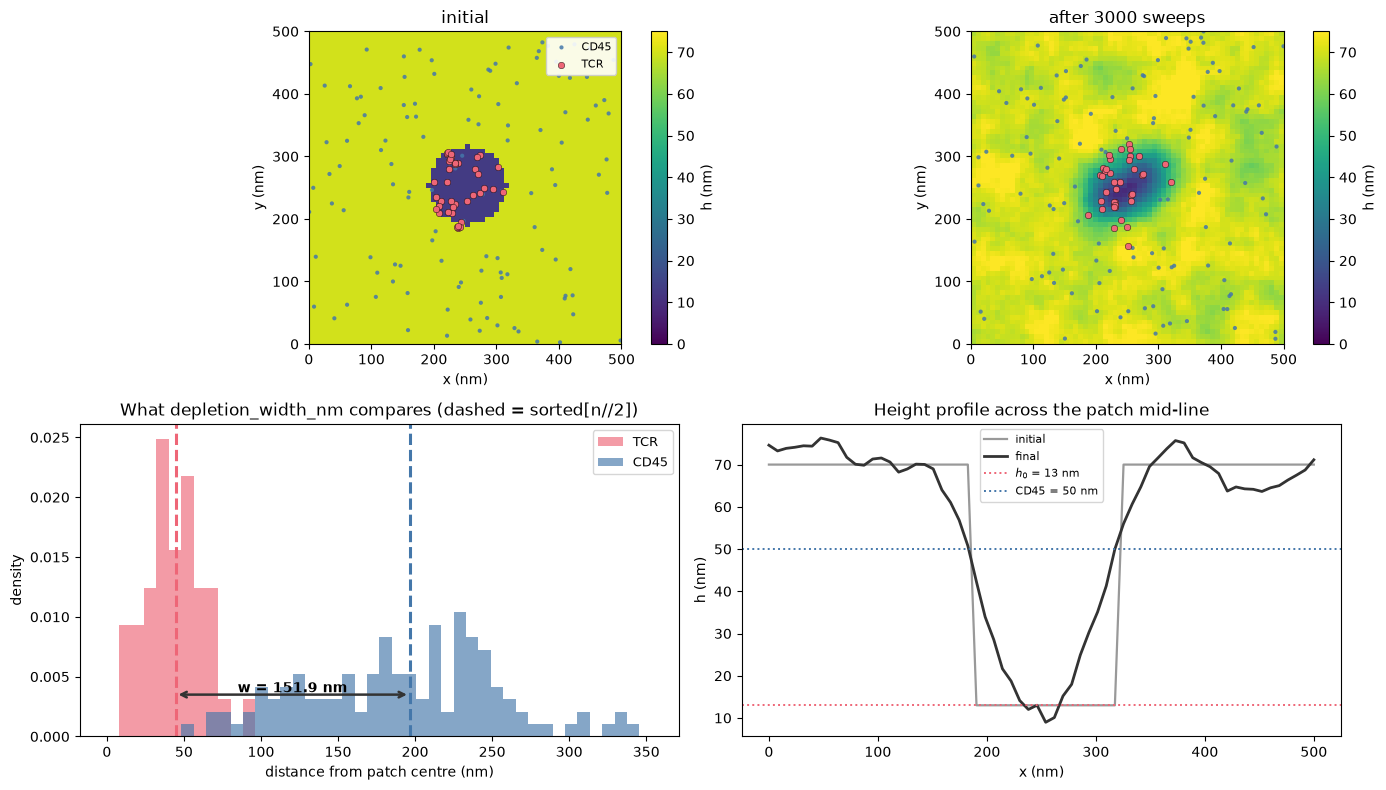

In [7]:
fig = plt.figure(figsize=(14, 8))
extent = [0, meta["patch_nm"], 0, meta["patch_nm"]]

for col, (hh, tt, cc, label) in enumerate([
    (h_initial, tcr0, cd450, "initial"),
    (h_final, tcr, cd45, f"after {meta['n_steps']} sweeps"),
]):
    ax = fig.add_subplot(2, 2, col + 1)
    im = ax.imshow(hh, origin="lower", extent=extent, cmap="viridis", vmin=0, vmax=75)
    ax.scatter(*cc.T, s=9, color=COLOR_CD45, label="CD45", edgecolors="none", alpha=0.85)
    ax.scatter(*tt.T, s=22, color=COLOR_TCR, label="TCR", edgecolors="k", linewidths=0.3)
    ax.set_title(f"{label}"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    if col == 0:
        ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    fig.colorbar(im, ax=ax, label="h (nm)", fraction=0.046)

# Radial distributions -- what the metric actually compares.
ax = fig.add_subplot(2, 2, 3)
bins = np.linspace(0, meta["patch_nm"] * 0.7072, 45)
ax.hist(r_tcr, bins=bins, color=COLOR_TCR, alpha=0.65, density=True, label="TCR")
ax.hist(r_cd45, bins=bins, color=COLOR_CD45, alpha=0.65, density=True, label="CD45")
ax.axvline(c_median(r_tcr), color=COLOR_TCR, lw=2.2, ls="--")
ax.axvline(c_median(r_cd45), color=COLOR_CD45, lw=2.2, ls="--")
ax.annotate("", xy=(c_median(r_cd45), 0.0035), xytext=(c_median(r_tcr), 0.0035),
            arrowprops=dict(arrowstyle="<->", color="#333", lw=1.8))
ax.text((c_median(r_tcr) + c_median(r_cd45)) / 2, 0.0037,
        f"w = {reported:.1f} nm", ha="center", fontsize=10, weight="bold")
ax.set_xlabel("distance from patch centre (nm)"); ax.set_ylabel("density")
ax.set_title("What depletion_width_nm compares (dashed = sorted[n//2])")
ax.legend(fontsize=9)

# Height profile through the middle.
ax = fig.add_subplot(2, 2, 4)
mid = h_final.shape[0] // 2
xs = np.linspace(0, meta["patch_nm"], h_final.shape[1])
ax.plot(xs, h_initial[mid], color="#999", lw=1.6, label="initial")
ax.plot(xs, h_final[mid], color="#333", lw=2, label="final")
ax.axhline(13, color=COLOR_TCR, ls=":", lw=1.4, label="$h_0$ = 13 nm")
ax.axhline(50, color=COLOR_CD45, ls=":", lw=1.4, label="CD45 = 50 nm")
ax.set_xlabel("x (nm)"); ax.set_ylabel("h (nm)")
ax.set_title("Height profile across the patch mid-line"); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

### What to notice

- The initial state is deliberately seeded with a **central depressed disc** at
  $h_0 = 13$ nm — the simulation does not have to nucleate a contact from nothing.
  Whether that contact then *grows, holds, or relaxes away* is the result.
- TCRs start on top of pMHC positions (with a small jitter), so they begin clustered.
  CD45 starts uniform.
- In the radial histogram, the depletion width is just the gap between two dashed
  lines. That framing makes its weaknesses visible: it is a difference of two single
  order statistics, so it ignores the *shape* of both distributions entirely. Two very
  different configurations can share a value of `w`. KS 5 introduces the metrics that
  were added to cover exactly that blind spot.

## Scientific checkpoint

1. `depletion_width_nm` is clamped at zero. What real physical situation does that
   clamp hide, and which of the other metrics would reveal it?
2. The metric measures from the patch **centre**. When would that be the wrong origin?
3. You double `n_steps` and the depletion width changes. Give two very different
   explanations, and say how you would tell them apart.

<details>
<summary>Check yourself</summary>

1. It hides *inversion* — CD45 ending up closer to the centre than TCR, which is the
   opposite of segregation and a sign something is wrong (or that the contact
   dissolved). `depletion_percentile_gap_nm` is the one metric permitted to go
   negative, so it can show this.
2. Whenever the contact zone is not centred or not roughly circular — an off-centre
   contact makes every centre-referenced metric meaningless even though the
   segregation is perfectly good. The nearest-neighbour metrics
   (`..._nn_p10_nm`) are geometry-free and survive this.
3. Either (a) the system had not yet equilibrated and is still relaxing toward its
   steady state, or (b) it *had* equilibrated and you are seeing run-to-run noise from
   a single stochastic trajectory. Distinguish them by running several seeds at both
   step counts: a systematic drift is (a), overlapping spreads are (b). A time series
   via `--snapshot-interval` settles it directly.
</details>

## Where to go next

**KS 4 — Key parameters**: the three predictions you made in KS 1, tested.

In [8]:
# Final check: the reconstruction must match the simulator to floating-point noise.
assert abs(exact - reported) < 1e-9, f"reconstruction drifted: {exact} vs {reported}"
assert abs(naive - reported) > 1e-6, "np.median unexpectedly agreed -- rewrite the lesson"
assert result["diagnostics"]["depletion_bound_tcr_cd45_nn_p10_nm"] is None
assert 0.0 <= result["diagnostics"]["accept_rate"] <= 1.0
print("[KS_3 self-check OK]")

[KS_3 self-check OK]
